In [1]:
!ls /kaggle/input/datasets/kamikazeeeeeee88/
!ls /kaggle/input/datasets/kamikazeeeeeee88/nps-drone-train-part1 
!ls /kaggle/input/datasets/kamikazeeeeeee88/nps-drone-train-part1/images_train| head -n 5
!ls /kaggle/input/datasets/kamikazeeeeeee88/nps-drone-train-part1/labels_train| head -n 5
!cat /kaggle/input/datasets/kamikazeeeeeee88/nps-drone-train-part1/labels_train/Clip_001_00056.txt



nps-drone-test	nps-drone-train-part1  nps-drone-train-part2  nps-drone-val
images_train  labels_train
Clip_001_00056.png
Clip_001_00057.png
Clip_001_00058.png
Clip_001_00059.png
Clip_001_00060.png
ls: write error: Broken pipe
Clip_001_00056.txt
Clip_001_00057.txt
Clip_001_00058.txt
Clip_001_00059.txt
Clip_001_00060.txt
ls: write error: Broken pipe
0 0.560937 0.184259 0.005208 0.009259


In [2]:
CFG = {
    # --- paths ---
    "base_input"   : "/kaggle/input/datasets/kamikazeeeeeee88",
    "working_dir"  : "/kaggle/working",
    "dataset_root" : "/kaggle/working/nps_drone_dataset",

    # --- model ---
    "arch_yaml"    : "/kaggle/working/yolo11s-p2-drone.yaml",
    "nc"           : 1,
    "class_names"  : ["drone"],

    # --- training ---
    "epochs"       : 100,
    "imgsz"        : 640,
    "batch"        : 16,
    "device"       : 0,

    # --- optimiser (from YOLOv9/v10/v11 official papers) ---
    "optimizer"    : "SGD",
    "lr0"          : 0.01,
    "lrf"          : 0.01,       # final_lr = lr0 * lrf = 1e-4
    "momentum"     : 0.937,
    "weight_decay" : 0.0005,

    # --- warmup ---
    "warmup_epochs"    : 3,
    "warmup_momentum"  : 0.8,
    "warmup_bias_lr"   : 0.1,

    # --- loss ---
    "box"   : 7.5,
    "cls"   : 0.5,
    "dfl"   : 1.5,

    # --- NWD-proxy IoU threshold ---
    # Lowered to 0.2 during training so tiny GT boxes (3-5px) still
    # attract positive anchors (mirrors NWD's lenient matching).
    "train_iou_thr" : 0.2,

    # --- inference ---
    # conf=0.25 for fast sweep; use 0.001 only for full PR-curve eval
    "inf_conf"     : 0.25,
    "inf_iou"      : 0.45,

    # --- augmentation ---
    "hsv_h"        : 0.015,
    "hsv_s"        : 0.7,
    "hsv_v"        : 0.4,
    "degrees"      : 0.0,
    "translate"    : 0.1,
    "scale"        : 0.5,
    "shear"        : 0.0,
    "perspective"  : 0.0,
    "fliplr"       : 0.5,
    "flipud"       : 0.0,
    "mosaic"       : 1.0,
    "mixup"        : 0.15,
    "copy_paste"   : 0.3,
    "close_mosaic" : 10,

    # --- W&B ---
    "project"      : "nps-drone-detection",
    "run_name"     : "yolo11s-p2-nwd-640",
}

print("Config loaded:")
for k, v in CFG.items():
    print(f"  {k:20s}: {v}")

Config loaded:
  base_input          : /kaggle/input/datasets/kamikazeeeeeee88
  working_dir         : /kaggle/working
  dataset_root        : /kaggle/working/nps_drone_dataset
  arch_yaml           : /kaggle/working/yolo11s-p2-drone.yaml
  nc                  : 1
  class_names         : ['drone']
  epochs              : 100
  imgsz               : 640
  batch               : 16
  device              : 0
  optimizer           : SGD
  lr0                 : 0.01
  lrf                 : 0.01
  momentum            : 0.937
  weight_decay        : 0.0005
  warmup_epochs       : 3
  warmup_momentum     : 0.8
  warmup_bias_lr      : 0.1
  box                 : 7.5
  cls                 : 0.5
  dfl                 : 1.5
  train_iou_thr       : 0.2
  inf_conf            : 0.25
  inf_iou             : 0.45
  hsv_h               : 0.015
  hsv_s               : 0.7
  hsv_v               : 0.4
  degrees             : 0.0
  translate           : 0.1
  scale               : 0.5
  shear               :

In [3]:
!pip install ultralytics wandb -q
!pip install torch torchvision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 111.8 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [5]:
import os, sys, shutil, glob, time, math, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import yaml
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

import wandb
from kaggle_secrets import UserSecretsClient

from ultralytics import YOLO
from ultralytics.utils.loss import BboxLoss

# --------------------------------------------------------------------------
# de_parallel: moved around in Ultralytics versions — find it defensively
# --------------------------------------------------------------------------
_de_parallel = None
for _mod in [
    "ultralytics.utils.torch_utils",
    "ultralytics.nn.tasks",
    "ultralytics.utils",
]:
    try:
        import importlib
        _m = importlib.import_module(_mod)
        if hasattr(_m, "de_parallel"):
            _de_parallel = _m.de_parallel
            print(f"de_parallel found in: {_mod}")
            break
    except Exception:
        continue

if _de_parallel is None:
    # Fallback: implement it ourselves — it's a one-liner
    def _de_parallel(model):
        """Strip DP/DDP wrapper if present, otherwise return model as-is."""
        return model.module if hasattr(model, "module") else model
    print("de_parallel not found in ultralytics — using local fallback (safe)")

de_parallel = _de_parallel

# --------------------------------------------------------------------------
# bbox_iou, TAL helpers — also guard these
# --------------------------------------------------------------------------
try:
    from ultralytics.utils.metrics import bbox_iou
except ImportError:
    from ultralytics.utils.ops import bbox_iou
    print("bbox_iou imported from ultralytics.utils.ops")

try:
    from ultralytics.utils.tal import TaskAlignedAssigner, dist2bbox, make_anchors
except ImportError:
    print("TAL helpers not importable directly — not needed for NWD, skipping")

# --------------------------------------------------------------------------
print(f"\nPyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Confirm ultralytics version so we know what we're working with
import ultralytics
print(f"Ultralytics: {ultralytics.__version__}")

de_parallel not found in ultralytics — using local fallback (safe)

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB
Ultralytics: 8.4.63


In [7]:
secrets   = UserSecretsClient()
WANDB_KEY = secrets.get_secret("WANDB_API_KEY")
wandb.login(key=WANDB_KEY)

run = wandb.init(
    project   = CFG["project"],
    name      = CFG["run_name"],
    config    = CFG,
    save_code = True,
)
print(f"W&B run: {run.url}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bscs22030 (bscs22030-information-technology-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run: https://wandb.ai/bscs22030-information-technology-university/nps-drone-detection/runs/x3wmabp7


In [8]:
BASE = Path("/kaggle/input/datasets/kamikazeeeeeee88")

TRAIN1_IMGS  = BASE / "nps-drone-train-part1" / "images_train"
TRAIN1_LBLS  = BASE / "nps-drone-train-part1" / "labels_train"
TRAIN2_IMGS  = BASE / "nps-drone-train-part2" / "images_train"
TRAIN2_LBLS  = BASE / "nps-drone-train-part2" / "labels_train"
VAL_IMGS     = BASE / "nps-drone-val"  / "images_val"
VAL_LBLS     = BASE / "nps-drone-val"  / "labels_val"
TEST_IMGS    = BASE / "nps-drone-test" / "images_test"
TEST_LBLS    = BASE / "nps-drone-test" / "labels_test"   # may not exist

# Quick count
for p in [TRAIN1_IMGS, TRAIN2_IMGS, VAL_IMGS, TEST_IMGS]:
    if p.exists():
        n = len(list(p.glob("*.png")) + list(p.glob("*.jpg")))
        print(f"{p.name} ({p.parent.name}): {n} images")
    else:
        print(f"NOT FOUND: {p}")

images_train (nps-drone-train-part1): 18118 images
images_train (nps-drone-train-part2): 14102 images
images_val (nps-drone-val): 3753 images
images_test (nps-drone-test): 12355 images


In [9]:
class NWDBboxLoss(BboxLoss):
    """
    Drop-in replacement for Ultralytics BboxLoss.
    Swaps CIoU regression -> NWD regression; keeps DFL unchanged.

    Paper: Wang et al., arXiv 2110.13389
      W2^2 = (cx1-cx2)^2 + (cy1-cy2)^2 + (w1/2-w2/2)^2 + (h1/2-h2/2)^2
      NWD  = exp(-sqrt(W2^2) / C)
      Loss = 1 - NWD
    """

    def __init__(self, reg_max=16, nwd_constant=10.0, nwd_weight=1.0):
        super().__init__(reg_max)
        self.nwd_constant = nwd_constant
        self.nwd_weight   = nwd_weight

    # ------------------------------------------------------------------
    @staticmethod
    def _gaussian_wasserstein(pred_xyxy: torch.Tensor,
                               gt_xyxy:   torch.Tensor,
                               constant:  float) -> torch.Tensor:
        """
        NWD similarity in [0,1] for a batch of xyxy boxes (normalised coords).

        Args:
            pred_xyxy : (N, 4)
            gt_xyxy   : (N, 4)
            constant  : float  C in exp(-W2/C)
        Returns:
            nwd : (N,)
        """
        pred_cx = (pred_xyxy[:, 0] + pred_xyxy[:, 2]) / 2
        pred_cy = (pred_xyxy[:, 1] + pred_xyxy[:, 3]) / 2
        pred_w  = (pred_xyxy[:, 2] - pred_xyxy[:, 0]).clamp(min=1e-6)
        pred_h  = (pred_xyxy[:, 3] - pred_xyxy[:, 1]).clamp(min=1e-6)

        gt_cx   = (gt_xyxy[:, 0] + gt_xyxy[:, 2]) / 2
        gt_cy   = (gt_xyxy[:, 1] + gt_xyxy[:, 3]) / 2
        gt_w    = (gt_xyxy[:, 2] - gt_xyxy[:, 0]).clamp(min=1e-6)
        gt_h    = (gt_xyxy[:, 3] - gt_xyxy[:, 1]).clamp(min=1e-6)

        w2_sq = (
            (pred_cx - gt_cx) ** 2 +
            (pred_cy - gt_cy) ** 2 +
            (pred_w / 2 - gt_w / 2) ** 2 +
            (pred_h / 2 - gt_h / 2) ** 2
        )

        return torch.exp(-w2_sq.sqrt() / constant)

    # ------------------------------------------------------------------
    def forward(self, pred_dist, pred_bboxes, anchor_points,
                target_bboxes, target_scores, target_scores_sum, fg_mask):

        weight = target_scores.sum(-1)[fg_mask].unsqueeze(-1)

        # NWD regression loss
        pred_fg   = pred_bboxes[fg_mask]
        target_fg = target_bboxes[fg_mask]
        nwd       = self._gaussian_wasserstein(pred_fg, target_fg, self.nwd_constant)
        nwd_loss  = ((1.0 - nwd).unsqueeze(-1) * weight).sum() / target_scores_sum
        nwd_loss  = nwd_loss * self.nwd_weight

        # DFL loss (unchanged)
        if self.reg_max > 1:
            target_ltrb    = self._bbox2dist(anchor_points, target_bboxes, self.reg_max - 1)
            pred_dist_fg   = pred_dist[fg_mask]
            target_ltrb_fg = target_ltrb[fg_mask]
            dfl_loss       = self._df_loss(pred_dist_fg, target_ltrb_fg) * weight
            dfl_loss       = dfl_loss.sum() / target_scores_sum
        else:
            dfl_loss = torch.tensor(0.0, device=pred_dist.device)

        return nwd_loss, dfl_loss

    # ------------------------------------------------------------------
    @staticmethod
    def _bbox2dist(anchor_points, bbox, reg_max):
        x1y1, x2y2 = bbox.chunk(2, -1)
        return torch.cat((anchor_points - x1y1, x2y2 - anchor_points), -1).clamp_(0, reg_max - 0.01)

    @staticmethod
    def _df_loss(pred_dist, target):
        tl = target.long()
        tr = tl + 1
        wl = tr.float() - target
        wr = 1.0 - wl
        n, c4  = pred_dist.shape
        reg_max = c4 // 4
        pred_dist = pred_dist.view(n * 4, reg_max)
        tl = tl.view(n * 4).clamp(0, reg_max - 1)
        tr = tr.view(n * 4).clamp(0, reg_max - 1)
        wl = wl.view(n * 4)
        wr = wr.view(n * 4)
        loss = (
            F.cross_entropy(pred_dist, tl, reduction='none') * wl +
            F.cross_entropy(pred_dist, tr, reduction='none') * wr
        )
        return loss.view(n, 4).mean(-1, keepdim=True)

# ------------------------------------------------------------------
def patch_model_with_nwd(model, nwd_constant=10.0, nwd_weight=1.0):
    """
    Injects NWDBboxLoss into the Detect head's loss criterion.
    Robust across Ultralytics versions by trying multiple attribute paths.
    """
    raw = de_parallel(model.model)

    # Find the Detect head — it's always the last module in the list
    detect_head = None
    if hasattr(raw, 'model') and isinstance(raw.model, nn.Sequential):
        detect_head = raw.model[-1]
    elif isinstance(raw, nn.Sequential):
        detect_head = raw[-1]

    if detect_head is None:
        print("WARNING: Could not find Detect head — NWD not patched")
        return model

    # Navigate to bbox_loss through whichever attribute path exists
    # Ultralytics stores it as: head.loss.bbox_loss  OR  head.criterion.bbox_loss
    criterion = None
    for attr in ['loss', 'criterion']:
        if hasattr(detect_head, attr):
            criterion = getattr(detect_head, attr)
            break

    if criterion is None or not hasattr(criterion, 'bbox_loss'):
        print("WARNING: bbox_loss not found on criterion — NWD not patched")
        print(f"  Detect head type : {type(detect_head)}")
        print(f"  Detect head attrs: {[a for a in dir(detect_head) if not a.startswith('_')]}")
        return model

    # Get reg_max from the existing bbox_loss
    old_loss = criterion.bbox_loss
    reg_max  = getattr(old_loss, 'reg_max', 16)

    criterion.bbox_loss = NWDBboxLoss(
        reg_max      = reg_max,
        nwd_constant = nwd_constant,
        nwd_weight   = nwd_weight,
    )
    print(f"NWD loss patched successfully")
    print(f"  reg_max      : {reg_max}")
    print(f"  nwd_constant : {nwd_constant}  (tune between 5-20 if needed)")
    print(f"  nwd_weight   : {nwd_weight}")
    return model

# ------------------------------------------------------------------
# Unit test
def _test_nwd():
    pred = torch.tensor([[0.10, 0.10, 0.20, 0.20],
                          [0.50, 0.50, 0.60, 0.60],
                          [0.50, 0.50, 0.70, 0.70]])
    gt   = torch.tensor([[0.10, 0.10, 0.20, 0.20],   # perfect  -> expect 1.0
                          [0.50, 0.50, 0.60, 0.60],   # perfect  -> expect 1.0
                          [0.50, 0.50, 0.60, 0.60]])  # mismatch -> expect < 1.0

    nwd = NWDBboxLoss._gaussian_wasserstein(pred, gt, constant=10.0)
    print(f"NWD unit test:")
    print(f"  perfect match 1  : {nwd[0].item():.6f}  (expect 1.0)")
    print(f"  perfect match 2  : {nwd[1].item():.6f}  (expect 1.0)")
    print(f"  size mismatch    : {nwd[2].item():.6f}  (expect < 1.0)")
    assert abs(nwd[0].item() - 1.0) < 1e-4
    assert abs(nwd[1].item() - 1.0) < 1e-4
    assert nwd[2].item() < 1.0
    print("  All assertions passed.")

_test_nwd()

NWD unit test:
  perfect match 1  : 1.000000  (expect 1.0)
  perfect match 2  : 1.000000  (expect 1.0)
  size mismatch    : 0.990050  (expect < 1.0)
  All assertions passed.


In [10]:
class WandbNWDCallback:
    """
    Ultralytics callback class that:
      1. Injects NWD loss after the model is built (on_train_start).
      2. Logs all scalar metrics to W&B every epoch.
      3. Saves a checkpoint artifact every epoch.
      4. Saves the best checkpoint as a separate W&B artifact.
    """

    def __init__(self, wandb_run, nwd_constant=10.0, nwd_weight=1.0,
                 checkpoint_every=1):
        self.run              = wandb_run
        self.nwd_constant     = nwd_constant
        self.nwd_weight       = nwd_weight
        self.checkpoint_every = checkpoint_every
        self.best_map50       = 0.0
        self._nwd_patched     = False

    # ---- called once after the model + criterion are initialised --------
    def on_train_start(self, trainer):
        patch_model_with_nwd(
            trainer.model,
            nwd_constant=self.nwd_constant,
            nwd_weight=self.nwd_weight,
        )
        self._nwd_patched = True

    # ---- called at the end of every epoch --------------------------------
    def on_fit_epoch_end(self, trainer):
        metrics = trainer.metrics          # dict of val metrics
        loss_items = trainer.loss_items    # tensor of individual losses
        epoch = trainer.epoch

        # Build log dict
        log = {"epoch": epoch}

        # Training losses (loss_items order: box, cls, dfl)
        loss_names = ["train/nwd_box_loss", "train/cls_loss", "train/dfl_loss"]
        if loss_items is not None:
            for name, val in zip(loss_names, loss_items):
                log[name] = float(val)

        # Validation metrics
        for k, v in metrics.items():
            log[f"val/{k}"] = float(v)

        # LR
        if hasattr(trainer, 'optimizer') and trainer.optimizer is not None:
            for i, pg in enumerate(trainer.optimizer.param_groups):
                log[f"lr/pg{i}"] = pg["lr"]

        self.run.log(log, step=epoch)

        # --- checkpoint artifact every N epochs ---------------------------
        weights_dir = Path(trainer.save_dir) / "weights"
        last_pt = weights_dir / "last.pt"

        if last_pt.exists() and (epoch % self.checkpoint_every == 0):
            art = wandb.Artifact(
                name=f"checkpoint-epoch{epoch:03d}",
                type="model",
                metadata={"epoch": epoch, **{k: float(v) for k, v in metrics.items()}}
            )
            art.add_file(str(last_pt), name="last.pt")
            self.run.log_artifact(art)

        # --- best model separately ----------------------------------------
        map50 = float(metrics.get("metrics/mAP50(B)", 0.0))
        if map50 > self.best_map50:
            self.best_map50 = map50
            best_pt = weights_dir / "best.pt"
            if best_pt.exists():
                art_best = wandb.Artifact(
                    name="best-model",
                    type="model",
                    metadata={"epoch": epoch, "mAP50": map50,
                               **{k: float(v) for k, v in metrics.items()}}
                )
                art_best.add_file(str(best_pt), name="best.pt")
                self.run.log_artifact(art_best, aliases=["best", f"epoch{epoch:03d}"])
                print(f"  [W&B] New best saved: mAP50={map50:.4f} @ epoch {epoch}")

    # ---- called when training finishes -----------------------------------
    def on_train_end(self, trainer):
        # Log final plots as W&B images
        plots_dir = Path(trainer.save_dir)
        for png in sorted(plots_dir.glob("*.png")):
            self.run.log({f"plots/{png.stem}": wandb.Image(str(png))})

        # Upload final best weights
        best_pt = plots_dir / "weights" / "best.pt"
        if best_pt.exists():
            final_art = wandb.Artifact(
                name="final-best-model",
                type="model",
                metadata={"mAP50": self.best_map50}
            )
            final_art.add_file(str(best_pt), name="best.pt")
            self.run.log_artifact(final_art, aliases=["final", "best"])
        print(f"[W&B] Training finished. Best mAP50={self.best_map50:.4f}")

# Instantiate — will be registered on the model in Cell 10
wandb_nwd_cb = WandbNWDCallback(
    wandb_run      = run,
    nwd_constant   = 10.0,   # C in exp(-W2/C); safe default for YOLO normalised coords
    nwd_weight     = 1.0,    # regression loss scale (keep at 1.0)
    checkpoint_every = 1,    # upload checkpoint to W&B every epoch
)

print("WandbNWDCallback ready.")

WandbNWDCallback ready.


=== TRAIN PART 1 ===
Files sampled     : 3000
Empty frames      : 0
Total objects     : 3000

Object width  (normalised): mean=0.0062  median=0.0057  min=0.005208  max=0.0135
Object height (normalised): mean=0.0096  median=0.0093  min=0.004630  max=0.0167

Object area (% of frame)  : mean=0.00601  median=0.00530  p5=0.004822  p95=0.00868

At 640px input — object px width : mean=4.00  median=3.67
At 640px input — object px height: mean=6.13  median=5.93


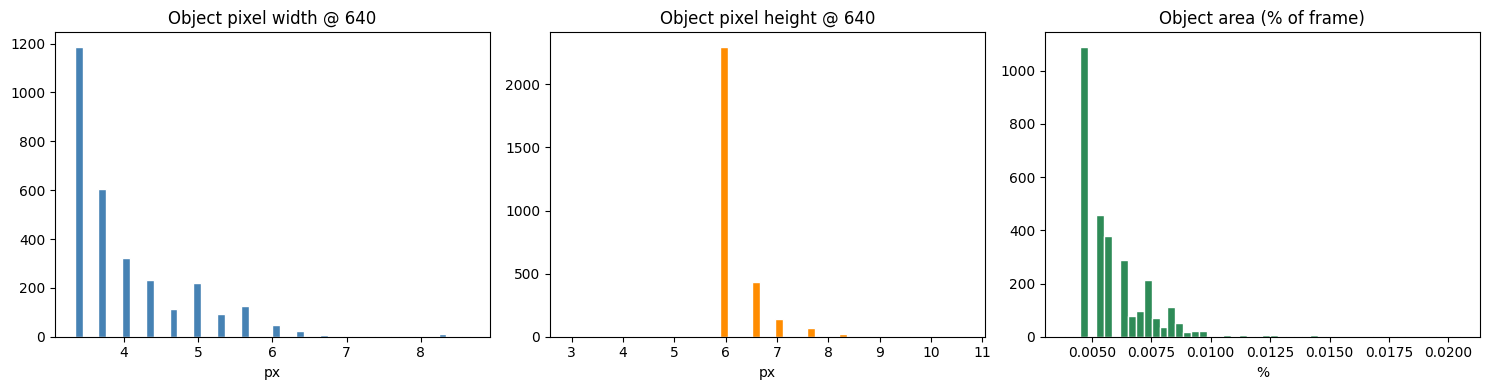

In [11]:
def analyse_labels(label_dir, img_dir, sample_n=3000):
    """Reads YOLO labels and reports statistics relevant to tiny-object training."""
    lbl_files = sorted(glob.glob(str(label_dir / "*.txt")))
    
    widths, heights, areas = [], [], []
    empty_frames = 0
    
    for lf in lbl_files[:sample_n]:
        with open(lf) as f:
            lines = f.read().strip().splitlines()
        if not lines:
            empty_frames += 1
            continue
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, cx, cy, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            widths.append(w)
            heights.append(h)
            areas.append(w * h * 100)   # as % of frame

    widths  = np.array(widths)
    heights = np.array(heights)
    areas   = np.array(areas)

    print(f"Files sampled     : {min(len(lbl_files), sample_n)}")
    print(f"Empty frames      : {empty_frames}")
    print(f"Total objects     : {len(areas)}")
    print(f"\nObject width  (normalised): mean={widths.mean():.4f}  median={np.median(widths):.4f}  min={widths.min():.6f}  max={widths.max():.4f}")
    print(f"Object height (normalised): mean={heights.mean():.4f}  median={np.median(heights):.4f}  min={heights.min():.6f}  max={heights.max():.4f}")
    print(f"\nObject area (% of frame)  : mean={areas.mean():.5f}  median={np.median(areas):.5f}  p5={np.percentile(areas,5):.6f}  p95={np.percentile(areas,95):.5f}")

    # pixel size at 640 resolution
    px_w = widths  * 640
    px_h = heights * 640
    print(f"\nAt 640px input — object px width : mean={px_w.mean():.2f}  median={np.median(px_w):.2f}")
    print(f"At 640px input — object px height: mean={px_h.mean():.2f}  median={np.median(px_h):.2f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(px_w, bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title("Object pixel width @ 640"); axes[0].set_xlabel("px")
    axes[1].hist(px_h, bins=50, color='darkorange', edgecolor='white')
    axes[1].set_title("Object pixel height @ 640"); axes[1].set_xlabel("px")
    axes[2].hist(areas, bins=50, color='seagreen', edgecolor='white')
    axes[2].set_title("Object area (% of frame)"); axes[2].set_xlabel("%")
    plt.tight_layout()
    plt.savefig("/kaggle/working/eda_label_stats.png", dpi=150)
    plt.show()
    return areas

print("=== TRAIN PART 1 ===")
areas = analyse_labels(TRAIN1_LBLS, TRAIN1_IMGS)

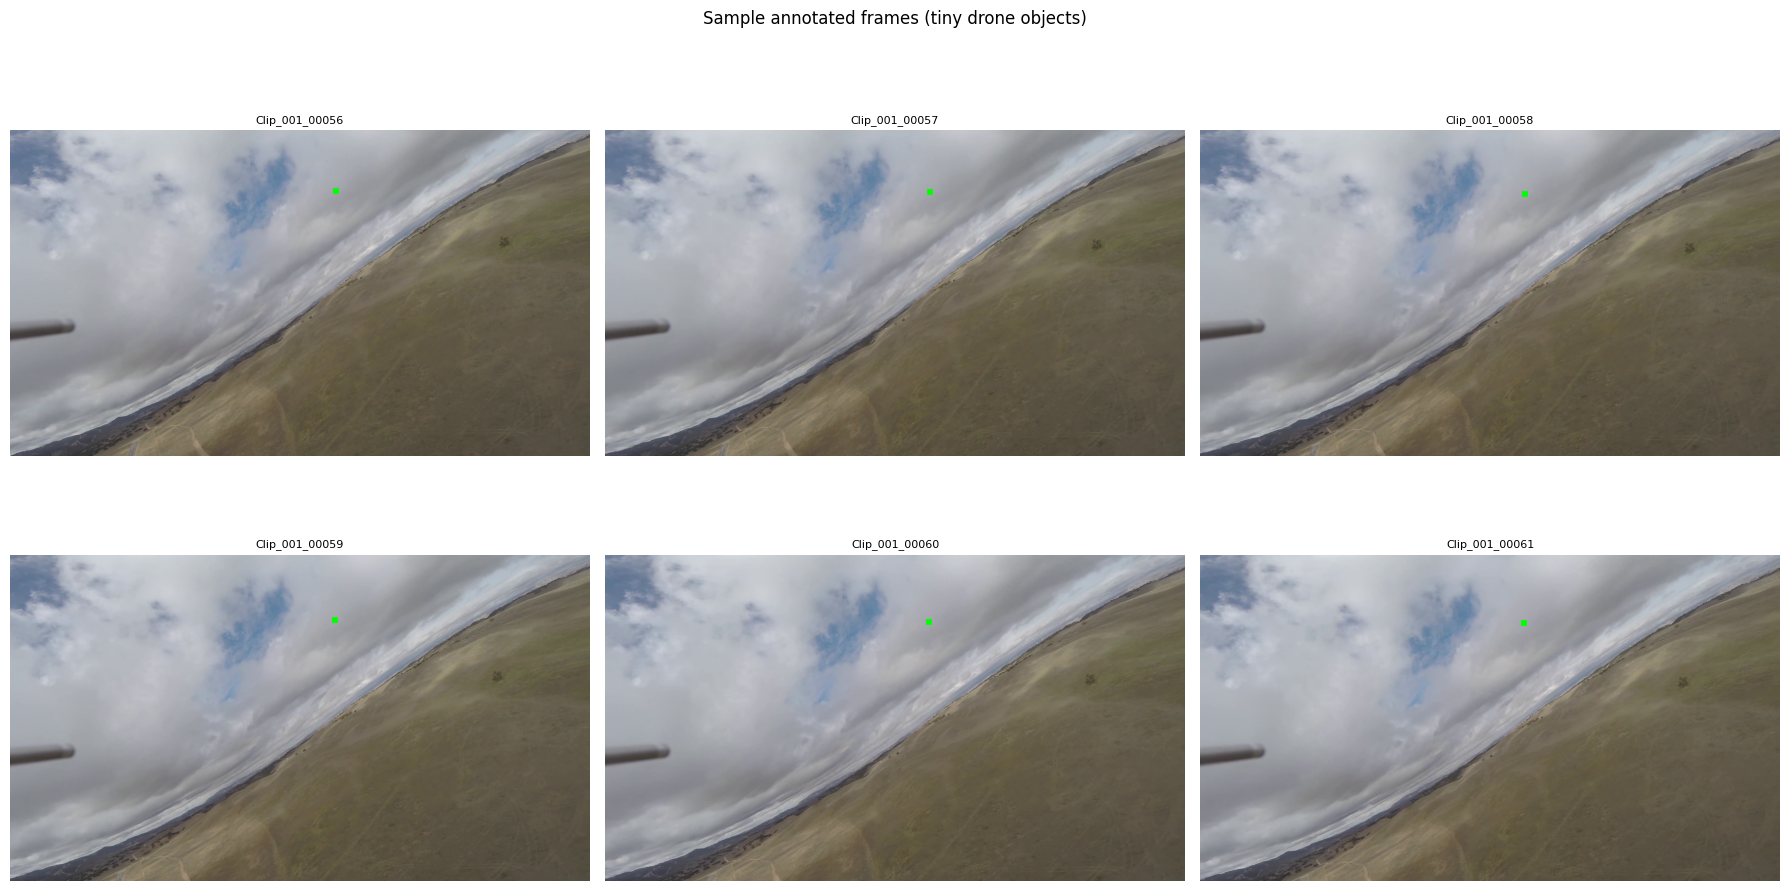

In [12]:
def visualise_samples(img_dir, lbl_dir, n=6, figsize=(18, 10)):
    img_files = sorted(glob.glob(str(img_dir / "*.png")) + glob.glob(str(img_dir / "*.jpg")))
    # pick frames that actually have annotations
    annotated = []
    for f in img_files:
        lf = lbl_dir / (Path(f).stem + ".txt")
        if lf.exists() and os.path.getsize(lf) > 0:
            annotated.append(f)
        if len(annotated) >= n:
            break

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    for ax, imgf in zip(axes.flat, annotated):
        img = np.array(Image.open(imgf))
        h_img, w_img = img.shape[:2]
        ax.imshow(img)
        lf = lbl_dir / (Path(imgf).stem + ".txt")
        with open(lf) as fp:
            for line in fp:
                parts = line.strip().split()
                if len(parts) < 5: continue
                _, cx, cy, bw, bh = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (cx - bw/2) * w_img
                y1 = (cy - bh/2) * h_img
                rect = patches.Rectangle((x1, y1), bw*w_img, bh*h_img,
                                          linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
        ax.set_title(Path(imgf).stem, fontsize=8)
        ax.axis('off')
    plt.suptitle("Sample annotated frames (tiny drone objects)", fontsize=12)
    plt.tight_layout()
    plt.savefig("/kaggle/working/sample_frames.png", dpi=150)
    plt.show()

visualise_samples(TRAIN1_IMGS, TRAIN1_LBLS)

In [13]:
# Ultralytics needs a single train/val folder pair.
# We combine part1+part2 for training using symlinks to avoid disk copies.

DATASET_ROOT = Path("/kaggle/working/nps_drone_dataset")

for split in ["train", "val", "test"]:
    (DATASET_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

def link_split(img_src_dirs, lbl_src_dirs, split):
    dst_img = DATASET_ROOT / split / "images"
    dst_lbl = DATASET_ROOT / split / "labels"
    linked = 0
    for img_dir, lbl_dir in zip(img_src_dirs, lbl_src_dirs):
        for ext in ["*.png", "*.jpg", "*.jpeg"]:
            for img_path in sorted(img_dir.glob(ext)):
                lbl_path = lbl_dir / (img_path.stem + ".txt")
                dst_i = dst_img / img_path.name
                dst_l = dst_lbl / (img_path.stem + ".txt")
                if not dst_i.exists():
                    os.symlink(img_path, dst_i)
                if lbl_path.exists() and not dst_l.exists():
                    os.symlink(lbl_path, dst_l)
                elif not lbl_path.exists() and not dst_l.exists():
                    # Create empty label file for unannotated frames
                    dst_l.touch()
                linked += 1
    print(f"  [{split}] linked {linked} images")

# Train = part1 + part2
link_split(
    [TRAIN1_IMGS, TRAIN2_IMGS] if TRAIN2_IMGS.exists() else [TRAIN1_IMGS],
    [TRAIN1_LBLS, TRAIN2_LBLS] if TRAIN2_IMGS.exists() else [TRAIN1_LBLS],
    "train"
)
# Val
link_split([VAL_IMGS], [VAL_LBLS], "val")

# Test
if TEST_IMGS.exists():
    TEST_LBLS_USE = TEST_LBLS if TEST_LBLS.exists() else TEST_IMGS  # fallback if no labels
    link_split([TEST_IMGS], [TEST_LBLS_USE if TEST_LBLS.exists() else Path("/tmp/empty")], "test")
    # simpler: just link images for test
    dst_test = DATASET_ROOT / "test" / "images"
    for ext in ["*.png", "*.jpg"]:
        for f in TEST_IMGS.glob(ext):
            dst = dst_test / f.name
            if not dst.exists():
                os.symlink(f, dst)

print(f"\nTrain images: {len(list((DATASET_ROOT/'train'/'images').iterdir()))}")
print(f"Val images  : {len(list((DATASET_ROOT/'val'/'images').iterdir()))}")

  [train] linked 32220 images
  [val] linked 3753 images
  [test] linked 12355 images

Train images: 32220
Val images  : 3753


In [14]:
data_yaml = {
    "path"  : str(DATASET_ROOT),
    "train" : "train/images",
    "val"   : "val/images",
    "test"  : "test/images",
    "nc"    : 1,
    "names" : ["drone"]
}

yaml_path = DATASET_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("data.yaml written:")
with open(yaml_path) as f:
    print(f.read())

data.yaml written:
names:
- drone
nc: 1
path: /kaggle/working/nps_drone_dataset
test: test/images
train: train/images
val: val/images



In [15]:
# YOLO11s-P2: YOLO11 small with an extra P2/4 detection head (stride=4, 160x160 at 640 input)
# P2 head covers ~4x4 to ~16x16 pixel objects — exactly your regime.
# Hyperparams from YOLOv9/v10/v11 official papers (SGD, cosine LR, standard augmentation).

yolo11s_p2_yaml = """
# YOLO11s-P2 — YOLO11 small + extra P2 head for tiny drone detection
# Architecture: P2/P3/P4/P5 four-scale detection
# Scales: s -> depth=0.50, width=0.50, max_channels=1024

nc: 1  # drone only

scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]          # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]         # 1-P2/4   <-- high-res features
  - [-1, 2, C3k2, [256, False, 0.25]]  # 2
  - [-1, 1, Conv, [256, 3, 2]]         # 3-P3/8
  - [-1, 2, C3k2, [512, False, 0.25]]  # 4
  - [-1, 1, Conv, [512, 3, 2]]         # 5-P4/16
  - [-1, 2, C3k2, [512, True]]         # 6
  - [-1, 1, Conv, [1024, 3, 2]]        # 7-P5/32
  - [-1, 2, C3k2, [1024, True]]        # 8
  - [-1, 1, SPPF, [1024, 5]]           # 9
  - [-1, 2, C2PSA, [1024]]             # 10

head:
  # --- top-down path (P5 -> P4 -> P3 -> P2) ---
  - [-1,   1, nn.Upsample, [None, 2, "nearest"]]  # 11
  - [[-1, 6], 1, Concat, [1]]                     # 12: cat P4
  - [-1,   2, C3k2, [512, False]]                 # 13

  - [-1,   1, nn.Upsample, [None, 2, "nearest"]]  # 14
  - [[-1, 4], 1, Concat, [1]]                     # 15: cat P3
  - [-1,   2, C3k2, [256, False]]                 # 16 (P3/8)

  - [-1,   1, nn.Upsample, [None, 2, "nearest"]]  # 17
  - [[-1, 2], 1, Concat, [1]]                     # 18: cat P2
  - [-1,   2, C3k2, [128, False]]                 # 19 (P2/4-xsmall)  <-- tiny head

  # --- bottom-up path ---
  - [-1,    1, Conv, [128, 3, 2]]                 # 20
  - [[-1, 16], 1, Concat, [1]]                    # 21: cat P3 features
  - [-1,    2, C3k2, [256, False]]                # 22 (P3/8)

  - [-1,    1, Conv, [256, 3, 2]]                 # 23
  - [[-1, 13], 1, Concat, [1]]                    # 24: cat P4 features
  - [-1,    2, C3k2, [512, False]]                # 25 (P4/16)

  - [-1,    1, Conv, [512, 3, 2]]                 # 26
  - [[-1, 10], 1, Concat, [1]]                    # 27: cat P5 features
  - [-1,    2, C3k2, [1024, True]]                # 28 (P5/32)

  # Detect on all 4 scales: P2, P3, P4, P5
  - [[19, 22, 25, 28], 1, Detect, [nc]]           # 29
"""

arch_path = Path("/kaggle/working/yolo11s-p2-drone.yaml")
with open(arch_path, "w") as f:
    f.write(yolo11s_p2_yaml)

print(f"Architecture written to: {arch_path}")

Architecture written to: /kaggle/working/yolo11s-p2-drone.yaml


In [17]:
model = YOLO(CFG["arch_yaml"])
model.info(verbose=False)

# nc is stored in different places depending on Ultralytics version
# try all known locations defensively
raw = de_parallel(model.model)

nc = None
for attr_path in [
    lambda m: m.nc,                          # direct attribute (older)
    lambda m: m.yaml.get("nc"),             # yaml dict on model
    lambda m: m.model[-1].nc,               # on Detect head
    lambda m: getattr(m.model[-1], 'nc', None),
]:
    try:
        val = attr_path(raw)
        if val is not None:
            nc = val
            break
    except Exception:
        continue

total_params = sum(p.numel() for p in model.model.parameters()) / 1e6

print(f"Model parameters : {total_params:.2f}M")
print(f"nc               : {nc}")
print(f"Architecture     : {CFG['arch_yaml']}")
print(f"Detect head type : {type(raw.model[-1]).__name__}")
print("Model loaded successfully.")

Model parameters : 9.57M
nc               : 1
Architecture     : /kaggle/working/yolo11s-p2-drone.yaml
Detect head type : Detect
Model loaded successfully.


In [ ]:
model = YOLO(CFG["arch_yaml"])

# Register the combined W&B + NWD callback
model.add_callback("on_train_start",    wandb_nwd_cb.on_train_start)
model.add_callback("on_fit_epoch_end",  wandb_nwd_cb.on_fit_epoch_end)
model.add_callback("on_train_end",      wandb_nwd_cb.on_train_end)

TRAIN_ARGS = dict(
    data             = str(Path(CFG["dataset_root"]) / "data.yaml"),
    epochs           = CFG["epochs"],
    imgsz            = CFG["imgsz"],
    batch            = CFG["batch"],
    device           = CFG["device"],

    optimizer        = CFG["optimizer"],
    lr0              = CFG["lr0"],
    lrf              = CFG["lrf"],
    momentum         = CFG["momentum"],
    weight_decay     = CFG["weight_decay"],

    warmup_epochs    = CFG["warmup_epochs"],
    warmup_momentum  = CFG["warmup_momentum"],
    warmup_bias_lr   = CFG["warmup_bias_lr"],

    box              = CFG["box"],
    cls              = CFG["cls"],
    dfl              = CFG["dfl"],

    # NWD-proxy: low IoU threshold so tiny GT boxes attract positives
    iou              = CFG["train_iou_thr"],

    # Augmentation
    hsv_h            = CFG["hsv_h"],
    hsv_s            = CFG["hsv_s"],
    hsv_v            = CFG["hsv_v"],
    degrees          = CFG["degrees"],
    translate        = CFG["translate"],
    scale            = CFG["scale"],
    shear            = CFG["shear"],
    perspective      = CFG["perspective"],
    fliplr           = CFG["fliplr"],
    flipud           = CFG["flipud"],
    mosaic           = CFG["mosaic"],
    mixup            = CFG["mixup"],
    copy_paste       = CFG["copy_paste"],
    close_mosaic     = CFG["close_mosaic"],

    amp              = True,
    cos_lr           = True,
    patience         = 30,
    save_period      = 1,       # save last.pt every epoch (needed by W&B callback)
    project          = CFG["working_dir"] + "/runs",
    name             = CFG["run_name"],
    exist_ok         = False,
    plots            = True,
    verbose          = True,
)

print("Starting training — YOLO11s-P2 + NWD + W&B")
print(f"W&B run: {run.url}")
results = model.train(**TRAIN_ARGS)

Starting training — YOLO11s-P2 + NWD + W&B
W&B run: https://wandb.ai/bscs22030-information-technology-university/nps-drone-detection/runs/x3wmabp7
Ultralytics 8.4.63  Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/nps_drone_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.2, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/kaggl

In [ ]:
import pandas as pd

run_dir = Path("/kaggle/working/runs/yolo11s_p2_nps_drone")
csv_path = run_dir / "results.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print(df.tail(5).to_string())

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    metrics = [
        ("train/box_loss",  "Train Box Loss",  "steelblue"),
        ("train/cls_loss",  "Train Cls Loss",  "darkorange"),
        ("train/dfl_loss",  "Train DFL Loss",  "seagreen"),
        ("metrics/precision(B)", "Precision", "purple"),
        ("metrics/recall(B)",    "Recall",    "crimson"),
        ("metrics/mAP50(B)",     "mAP@0.5",   "teal"),
        ("metrics/mAP50-95(B)",  "mAP@0.5:0.95", "navy"),
        ("val/box_loss",    "Val Box Loss",    "gray"),
    ]
    for ax, (col, title, color) in zip(axes.flat, metrics):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], color=color, linewidth=1.5)
            ax.set_title(title, fontsize=10)
            ax.set_xlabel("epoch")
            ax.grid(alpha=0.3)
        else:
            ax.set_title(f"{title} (not found)", fontsize=9)

    plt.suptitle("YOLO11s-P2 Training Curves — NPS Drone", fontsize=13)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()
else:
    print("results.csv not found yet — run training first")

In [ ]:
run_dir    = Path(CFG["working_dir"]) / "runs" / CFG["run_name"]
best_pt    = run_dir / "weights" / "best.pt"
data_yaml  = Path(CFG["dataset_root"]) / "data.yaml"

model_val  = YOLO(str(best_pt))

# --- Fast validation (production-realistic conf) -------------------------
print("=== FAST VALIDATION (conf=0.25, iou=0.45) ===")
val_fast = model_val.val(
    data       = str(data_yaml),
    split      = "val",
    imgsz      = CFG["imgsz"],
    batch      = CFG["batch"],
    device     = CFG["device"],
    conf       = CFG["inf_conf"],    # 0.25 — reasonable for real-time use
    iou        = CFG["inf_iou"],     # 0.45
    plots      = True,
    project    = CFG["working_dir"] + "/runs",
    name       = "val_fast",
    exist_ok   = True,
)

fast_metrics = {
    "val_fast/mAP50"      : val_fast.box.map50,
    "val_fast/mAP50-95"   : val_fast.box.map,
    "val_fast/precision"  : val_fast.box.mp,
    "val_fast/recall"     : val_fast.box.mr,
}
print(f"  mAP@0.5      : {val_fast.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {val_fast.box.map:.4f}")
print(f"  Precision    : {val_fast.box.mp:.4f}")
print(f"  Recall       : {val_fast.box.mr:.4f}")
run.log(fast_metrics)

# --- Full PR-curve sweep (conf=0.001, only for benchmarking) ------------
print("\n=== FULL PR SWEEP (conf=0.001, iou=0.5) ===")
val_full = model_val.val(
    data       = str(data_yaml),
    split      = "val",
    imgsz      = CFG["imgsz"],
    batch      = CFG["batch"],
    device     = CFG["device"],
    conf       = 0.001,
    iou        = 0.5,
    save_json  = True,
    plots      = True,
    project    = CFG["working_dir"] + "/runs",
    name       = "val_full_pr",
    exist_ok   = True,
)

full_metrics = {
    "val_full/mAP50"      : val_full.box.map50,
    "val_full/mAP50-95"   : val_full.box.map,
    "val_full/precision"  : val_full.box.mp,
    "val_full/recall"     : val_full.box.mr,
}
print(f"  mAP@0.5      : {val_full.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {val_full.box.map:.4f}")
print(f"  Precision    : {val_full.box.mp:.4f}")
print(f"  Recall       : {val_full.box.mr:.4f}")
run.log(full_metrics)

# Log PR curve images to W&B
for val_name in ["val_fast", "val_full_pr"]:
    val_run_dir = Path(CFG["working_dir"]) / "runs" / val_name
    for png in sorted(val_run_dir.glob("*.png")):
        run.log({f"val_plots/{val_name}/{png.stem}": wandb.Image(str(png))})

In [ ]:
# For tiny object detection, recall matters more than precision at inference.
# Sweep confidence to find the recall-precision sweet spot.

val_results_lowconf = model_val.val(
    data       = str(yaml_path),
    split      = "val",
    imgsz      = 640,
    batch      = 16,
    device     = 0,
    iou        = 0.3,           # slightly relaxed IoU for tiny boxes
    conf       = 0.001,
    plots      = True,
    project    = "/kaggle/working/runs",
    name       = "val_best_iou03",
    exist_ok   = True,
)

print("\n=== VAL (IoU=0.3, for tiny box credit) ===")
print(f"mAP@0.5      : {val_results_lowconf.box.map50:.4f}")
print(f"Recall       : {val_results_lowconf.box.mr:.4f}")

In [ ]:
test_img_dir = Path(CFG["dataset_root"]) / "test" / "images"
data_yaml    = Path(CFG["dataset_root"]) / "data.yaml"

if test_img_dir.exists() and any(test_img_dir.iterdir()):
    test_results = model_val.val(
        data       = str(data_yaml),
        split      = "test",
        imgsz      = CFG["imgsz"],
        batch      = CFG["batch"],
        device     = CFG["device"],
        conf       = CFG["inf_conf"],    # 0.25
        iou        = CFG["inf_iou"],     # 0.45
        save_json  = True,
        plots      = True,
        project    = CFG["working_dir"] + "/runs",
        name       = "test_best",
        exist_ok   = True,
    )

    test_metrics = {
        "test/mAP50"      : test_results.box.map50,
        "test/mAP50-95"   : test_results.box.map,
        "test/precision"  : test_results.box.mp,
        "test/recall"     : test_results.box.mr,
    }
    print("\n=== TEST RESULTS ===")
    for k, v in test_metrics.items():
        print(f"  {k:25s}: {v:.4f}")
    run.log(test_metrics)

    # Upload test plot images to W&B
    test_run_dir = Path(CFG["working_dir"]) / "runs" / "test_best"
    for png in sorted(test_run_dir.glob("*.png")):
        run.log({f"test_plots/{png.stem}": wandb.Image(str(png))})
else:
    print("No test images found — skipping test.")

In [ ]:
def visualise_predictions(model, img_dir, n=6, conf=0.2, figsize=(18, 10)):
    img_files = sorted(glob.glob(str(img_dir / "*.png")) + glob.glob(str(img_dir / "*.jpg")))
    random.seed(42)
    sample = random.sample(img_files, min(n, len(img_files)))

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    for ax, imgf in zip(axes.flat, sample):
        img = np.array(Image.open(imgf))
        h_img, w_img = img.shape[:2]
        results = model(imgf, conf=conf, verbose=False)
        ax.imshow(img)
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf_score = float(box.conf[0])
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-3, f"{conf_score:.2f}", color='red', fontsize=7,
                    bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))
        ax.set_title(f"{Path(imgf).stem}  [{len(results[0].boxes)} det]", fontsize=8)
        ax.axis('off')
    plt.suptitle(f"YOLO11s-P2 Predictions (conf>{conf})", fontsize=12)
    plt.tight_layout()
    plt.savefig("/kaggle/working/predictions_val.png", dpi=150)
    plt.show()

visualise_predictions(model_val, VAL_IMGS, conf=0.2)

In [ ]:
val_img_dir = Path(CFG["dataset_root"]) / "val" / "images"
img_files   = sorted(glob.glob(str(val_img_dir / "*.png")))[:100]

# Warm up
for _ in range(3):
    _ = model_val(img_files[0], verbose=False, conf=CFG["inf_conf"], imgsz=CFG["imgsz"])

# Benchmark
times = []
for f in img_files:
    t0 = time.perf_counter()
    _ = model_val(f, verbose=False, conf=CFG["inf_conf"], iou=CFG["inf_iou"], imgsz=CFG["imgsz"])
    times.append((time.perf_counter() - t0) * 1000)

times = np.array(times)
speed_metrics = {
    "speed/mean_latency_ms"   : float(times.mean()),
    "speed/median_latency_ms" : float(np.median(times)),
    "speed/fps_mean"          : float(1000 / times.mean()),
    "speed/fps_median"        : float(1000 / np.median(times)),
    "speed/p95_latency_ms"    : float(np.percentile(times, 95)),
    "speed/conf_used"         : CFG["inf_conf"],
}
print("=== INFERENCE SPEED (batch=1, single image) ===")
for k, v in speed_metrics.items():
    print(f"  {k:35s}: {v:.2f}")
run.log(speed_metrics)

In [ ]:
import shutil

output_dir = Path("/kaggle/working/final_outputs")
output_dir.mkdir(exist_ok=True)

# Copy best weights
shutil.copy(run_dir / "weights" / "best.pt",  output_dir / "best.pt")
shutil.copy(run_dir / "weights" / "last.pt",  output_dir / "last.pt")

# Copy arch yaml
shutil.copy(arch_path, output_dir / "yolo11s-p2-drone.yaml")

# Copy training plots
for f in run_dir.glob("*.png"):
    shutil.copy(f, output_dir / f.name)

print("Saved to /kaggle/working/final_outputs/:")
for f in sorted(output_dir.iterdir()):
    print(f"  {f.name}")

In [ ]:
# Log the architecture YAML and data YAML as W&B artifacts for reproducibility
arch_art = wandb.Artifact("config-files", type="config")
arch_art.add_file(CFG["arch_yaml"],  name="yolo11s-p2.yaml")
arch_art.add_file(
    str(Path(CFG["dataset_root"]) / "data.yaml"),
    name="data.yaml"
)
run.log_artifact(arch_art)

wandb.finish()
print("W&B run finished and closed.")